# 🌍 Python in the Wild
### Demo Notebook
---
ไม่ต้องเขียนโค้ดเอง — แค่รันและดูผลลัพธ์

**ติดตั้งก่อนรัน**
```bash
pip install pandas matplotlib mediapipe opencv-python
```

---
# Part 1 — pandas
### วิเคราะห์ข้อมูลนักศึกษา

**pandas คืออะไร?**  
Library ที่ทำให้ Python จัดการข้อมูลตารางได้เหมือน Excel  
ข้อมูลจะถูกเก็บใน **DataFrame** — คิดว่ามันคือตารางที่มีแถวและคอลัมน์

**df คืออะไร?**  
`df` ย่อมาจาก DataFrame — เป็นชื่อตัวแปรที่นิยมใช้กัน ไม่ได้บังคับ  
เหมือนกับที่เราตั้งชื่อตัวแปรทั่วไป แต่ทุกคนในโลก Python ใช้ `df` เป็น convention

In [3]:
import pandas as pd

# สร้างข้อมูลนักศึกษาจำลองขึ้นมาโดยตรง
# ในงานจริงจะใช้ pd.read_csv("file.csv") แทน
data = {
    "name":  ["Alice", "Bob", "Carol", "David", "Eve",
              "Frank", "Grace", "Henry", "Iris", "Jack"],
    "score": [85, 42, 91, 60, 78, 35, 88, 55, 95, 67],
    "year":  [1, 2, 1, 3, 2, 1, 3, 2, 1, 3]
}

# pd.DataFrame() แปลง dict ให้กลายเป็นตาราง
df = pd.DataFrame(data)

# แสดงตารางทั้งหมด
print(df)

    name  score  year
0  Alice     85     1
1    Bob     42     2
2  Carol     91     1
3  David     60     3
4    Eve     78     2
5  Frank     35     1
6  Grace     88     3
7  Henry     55     2
8   Iris     95     1
9   Jack     67     3


In [4]:
# df.head(n) — แสดงแค่ n แถวแรก
# ใช้ดูคร่าวๆ ว่าข้อมูลหน้าตาเป็นยังไง โดยไม่ต้องดูทั้งหมด
print(df.head(3))

    name  score  year
0  Alice     85     1
1    Bob     42     2
2  Carol     91     1


In [5]:
# df.describe() — สรุปสถิติพื้นฐานของทุก column ที่เป็นตัวเลข
# count = จำนวนแถว, mean = ค่าเฉลี่ย, std = ความเบี่ยงเบน
# min/max = ต่ำสุด/สูงสุด, 25%/50%/75% = percentile
print(df.describe())

           score       year
count  10.000000  10.000000
mean   69.600000   1.900000
std    21.135541   0.875595
min    35.000000   1.000000
25%    56.250000   1.000000
50%    72.500000   2.000000
75%    87.250000   2.750000
max    95.000000   3.000000


In [6]:
# df["column"] — เลือกดูแค่ column เดียว
# ได้กลับมาเป็น Series (คิดว่าคือ list ที่มี index)
print(df["score"])

0    85
1    42
2    91
3    60
4    78
5    35
6    88
7    55
8    95
9    67
Name: score, dtype: int64


In [7]:
# df[condition] — กรองแถวตามเงื่อนไข
# df["score"] >= 60 สร้าง True/False ต่อแต่ละแถว
# แล้ว df[...] เอาเฉพาะแถวที่เป็น True
passed = df[df["score"] >= 60]
print(f"Passed: {len(passed)} students")
print(passed)

Passed: 7 students
    name  score  year
0  Alice     85     1
2  Carol     91     1
3  David     60     3
4    Eve     78     2
6  Grace     88     3
8   Iris     95     1
9   Jack     67     3


In [8]:
# เพิ่ม column ใหม่ได้เลย — Python คำนวณทุกแถวให้อัตโนมัติ
# ไม่ต้องวนลูปเอง pandas ทำให้
df["grade"] = df["score"].apply(
    lambda s: "A" if s >= 90 else
              "B" if s >= 80 else
              "C" if s >= 70 else
              "D" if s >= 60 else "F"
)
print(df[["name", "score", "grade"]])

    name  score grade
0  Alice     85     B
1    Bob     42     F
2  Carol     91     A
3  David     60     D
4    Eve     78     C
5  Frank     35     F
6  Grace     88     B
7  Henry     55     F
8   Iris     95     A
9   Jack     67     D


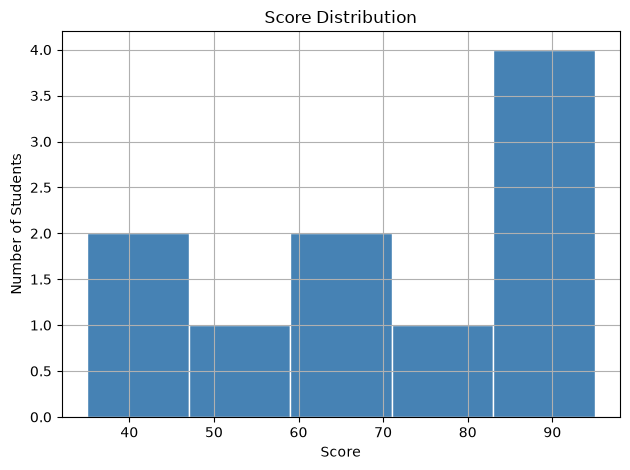

In [9]:
import matplotlib.pyplot as plt

# plot histogram — แสดงการกระจายของคะแนน
# bins = จำนวนช่วงที่แบ่ง, color = สีแท่ง, edgecolor = สีขอบ
df["score"].hist(bins=5, color="steelblue", edgecolor="white")

plt.title("Score Distribution")   # หัวข้อกราฟ
plt.xlabel("Score")                # แกน x
plt.ylabel("Number of Students")  # แกน y
plt.tight_layout()                 # จัดระยะให้พอดี
plt.show()

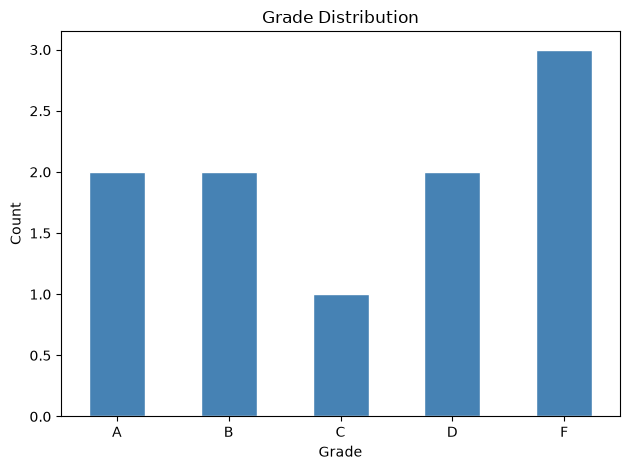

In [10]:
# นับจำนวนแต่ละ grade — value_counts() นับความถี่ของแต่ละค่า
grade_counts = df["grade"].value_counts().sort_index()

# plot bar chart
grade_counts.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.xticks(rotation=0)   # ให้ label แกน x ไม่หมุน
plt.tight_layout()
plt.show()

---
# Part 2 — MediaPipe
### นับนิ้วจากภาพ

**MediaPipe คืออะไร?**  
Library จาก Google ที่ตรวจจับ landmark บนร่างกายได้  
สำหรับมือ — ให้ **21 จุด** ต่อมือ 1 ข้าง แต่ละจุดมี x, y, z

**หลักการนับนิ้ว**  
แต่ละนิ้วมี 4 landmark — เช็คว่า **tip** (ปลายนิ้ว) อยู่สูงกว่า **pip** (ข้อกลาง) ไหม  
ถ้าสูงกว่า → นิ้วตั้ง → นับ 1

**วิธีใช้**  
เปลี่ยนชื่อไฟล์ภาพใน `IMAGE_PATH` แล้วรัน — ผลลัพธ์เปลี่ยนตามภาพที่ใส่

Detected 1 hand(s)


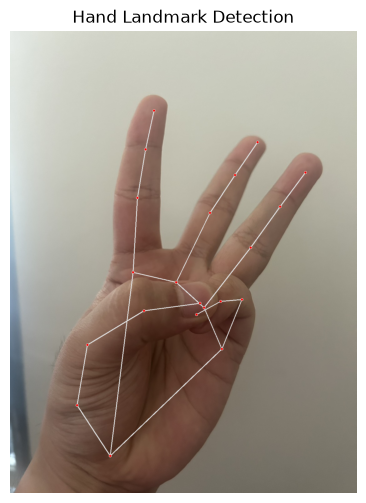

In [1]:
import cv2                          # อ่านและเขียนภาพ
import mediapipe as mp             # ตรวจจับ landmark
import matplotlib.pyplot as plt    # แสดงภาพใน notebook

# --- เปลี่ยนตรงนี้เพื่อทดสอบภาพอื่น ---
IMAGE_PATH = "h4.jpg"            # ใส่ path ของภาพมือที่ต้องการ
# ----------------------------------------

# โหลด module มือจาก mediapipe
mp_hands   = mp.solutions.hands           # model ตรวจจับมือ
mp_drawing = mp.solutions.drawing_utils   # ตัวช่วยวาด landmark

# อ่านภาพด้วย OpenCV
# OpenCV อ่านภาพมาเป็น BGR (ไม่ใช่ RGB) เป็น default ของมัน
img_bgr = cv2.imread(IMAGE_PATH)

# MediaPipe ต้องการ RGB — แปลงก่อน
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# สร้าง detector — static_image_mode=True บอกว่าใช้กับภาพนิ่ง ไม่ใช่ video
with mp_hands.Hands(static_image_mode=True, max_num_hands=2) as hands:
    
    # ส่งภาพเข้า model — ได้ผลลัพธ์กลับมาเป็น results object
    results = hands.process(img_rgb)

# ทำสำเนาภาพไว้วาดทับ ไม่แก้ต้นฉบับ
img_output = img_bgr.copy()

# ถ้าตรวจเจอมือ — results.multi_hand_landmarks จะไม่เป็น None
if results.multi_hand_landmarks:
    for hand_landmarks in results.multi_hand_landmarks:
        # วาด landmark และเส้นเชื่อมทุกจุดบนภาพ
        mp_drawing.draw_landmarks(
            img_output,                      # ภาพที่จะวาดทับ
            hand_landmarks,                  # ข้อมูล landmark
            mp_hands.HAND_CONNECTIONS        # เส้นเชื่อมระหว่าง landmark
        )
    print(f"Detected {len(results.multi_hand_landmarks)} hand(s)")
else:
    print("No hands detected — try a clearer image")

# แสดงภาพใน notebook (ต้องแปลง BGR กลับเป็น RGB ก่อน matplotlib จะแสดงสีถูก)
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img_output, cv2.COLOR_BGR2RGB))
plt.axis("off")   # ซ่อน axis
plt.title("Hand Landmark Detection")
plt.show()

In [3]:
# นับจำนวนนิ้วที่ตั้งอยู่
#
# MediaPipe ให้ index ของแต่ละ lanต่dmark ดังนี้ (อนิ้ว)
# TIP = ปลายนิ้ว, PIP = ข้อกลางนิ้ว
#
# นิ้วชี้  : TIP=8,  PIP=6
# นิ้วกลาง: TIP=12, PIP=10
# นิ้วนาง : TIP=16, PIP=14
# นิ้วก้อย : TIP=20, PIP=18
# นิ้วโป้ง : ใช้ x แทน y เพราะนิ้วโป้งตั้งในแนวนอน
#            TIP=4, MCP=2

# คู่ (tip_index, pip_index) ของนิ้ว 4 นิ้ว
FINGER_TIPS = [8, 12, 16, 20]
FINGER_PIPS = [6, 10, 14, 18]

if results.multi_hand_landmarks:
    for i, hand_landmarks in enumerate(results.multi_hand_landmarks):
        lm = hand_landmarks.landmark   # list ของ landmark ทั้ง 21 จุด
        
        fingers_up = 0
        
        # นับ 4 นิ้ว (ชี้ กลาง นาง ก้อย)
        # ถ้า y ของ tip น้อยกว่า pip แปลว่าอยู่สูงกว่า = นิ้วตั้ง
        # (y=0 อยู่บนสุดของภาพ y=1 อยู่ล่างสุด)
        for tip, pip in zip(FINGER_TIPS, FINGER_PIPS):
            if lm[tip].y < lm[pip].y:   # tip สูงกว่า pip = นิ้วตั้ง
                fingers_up += 1
        
        # นิ้วโป้ง — เช็คแนวนอน (x) แทน
        # ถ้า tip อยู่ซ้ายกว่า mcp = นิ้วโป้งกาง (มือขวา)
        if lm[4].x < lm[2].x:
            fingers_up += 1
        
        print(f"Hand {i+1}: {fingers_up} finger(s) up")
else:
    print("No hands detected")

Hand 1: 3 finger(s) up
